# Heuristické algoritmy / cv. 2026

## 1. Introduction

### About your lecturer

My name is Matej Mojzeš, and I will be your lecturer. I also:

* Hold a PhD in integer optimization heuristics from the Department of Software Engineering, FNSPE CTU in Prague  
* Lead the data team at [SharpGrid](https://www.sharpgrid.com) as the Head of Data (using heuristics, of course!)  
* Have over 15 years of experience in Business Intelligence, Data Warehousing, Engineering, and Data Science across both startup and corporate environments

### About this course

We will experiment with "black-box" optimization of various **objective functions** (e.g. Travelling Salesman Problem, Artificial Neural Network weight optimization, [benchmark function optimization](http://www.geatbx.com/docu/fcnindex-01.html)) using different kinds of **heuristics** (e.g. Simulated Annealing, Genetic Optimization, Differential Evolution).

Recommended tools for this course are **Python & Jupyter notebook**:
* Python: [reasons why](https://www.stat.washington.edu/~hoytak/blog/whypython.html), Jupyter notebook: [reasons why](http://www.nature.com/news/interactive-notebooks-sharing-the-code-1.16261),
* download & install from [here](https://www.continuum.io/downloads).

All **resources** will be on GitLab (link coming soon). Any meaningful pull requests will be taken into account during your evaluation.

### About _zápočet_

I will encourage you and help you to work on your own projects, which should ideally be your **custom objective functions** that you will optimize using the framework we build together. If you want, you can develop your own heuristics as well.

Your goal is to deliver your work in the form of a **research-style paper** with the source code attached (ideally as a Jupyter notebook).

#### Notes

* Subscribe to the mailing list: send me an e-mail with subject "HEURISTIKY 2026" to `matej.mojzes@fjfi.cvut.cz`.
* **DO NOT** try to begin working on your project in the last week of the school year (or before your final exams), chances are that:
  * you will not have enough time to deliver a project of acceptable quality and/or
  * I will be out of the office and off-line.
* Last, but not least, nota bene:

![Learning statistics](../figures/learning.jpeg)

Therefore, I offer you the possibility to actively participate in a "Show and tell" lecture, and I will improve your mark based on the successful presentation of your project

## 2. First assignment — optimizing a recommender system

Imagine you are tuning a large-scale recommender system.

The system has two hyperparameters:
$x$ — personalization strength
$y$ — exploration rate

Both are integers:

$$x, y \in \{0;99\}$$

So the search space contains $100 \times 100 = 10 000$ possible configurations.

**Your objective**

You want to maximize user engagement. However:
* The true engagement function is unknown (black-box).
* Each evaluation requires running an online A/B experiment.
* You have budget for only 100 evaluations.
* You know that the optimal engagement value corresponds to objective value: $f^* = 0$ (we will minimize the objective function).

**Task**

* Implement and your preferred heuristic.
* Simulate the experiment 1 000 times.
* For each run, record:
  - best objective value found
  - number of evaluations until optimum is first reached

**Today’s goal is to experience**:
- local minima traps
- budget constraints
- reliability vs performance trade-offs
- why heuristics are necessary

In [1]:
# the black-box

import numpy as np

# domain: x,y in [0; 99]
X0, Y0 = 37, 68   # global optimum location

def evaluate(x, y):
    # Global bowl (deepest -> true global minimum)
    g = 0.25*((x - X0)**2 + (y - Y0)**2)

    # Two sharp local minima ("traps")
    # Same quadratic shape, lifted by offsets so they are worse than global.
    t1 = 0.30*((x - 80)**2 + (y - 20)**2) + 18.0
    t2 = 0.35*((x - 15)**2 + (y - 85)**2) + 22.0

    return min(g, t1, t2)   # minimization objective

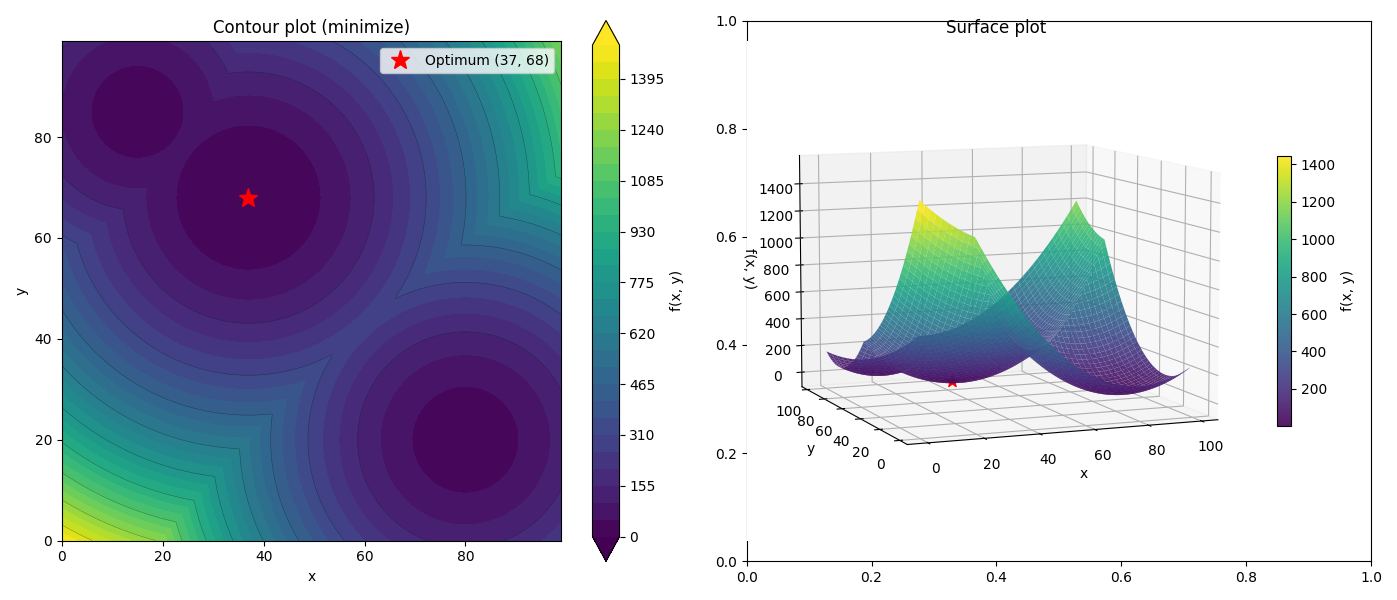

## 3. Results analysis

#### Questions / performance evaluation

1. In how many experiments was the optimum found? [reliability, in %]
2. What was the median number of evaluations needed (conditional on success)? [speed]
3. What was the median best objective value after 100 evaluations? [solution quality]
4. Which method is better under:
- reliability?
- speed?
- solution quality?

#### Let us compare two heuristics:

**Random Shooting (RS)**

Evaluates random configurations until:
a. optimum is found, or
b. evaluation budget (100) is exhausted.

**Shoot & Go (SG)**

Random restart hill climbing:
* Sample random configuration.
* Iteratively improve it using local neighborhood.
* Stop when no improving neighbor exists.
* Restart until budget exhausted.


### Summary comparison

| Metric                               | RS | SG   |
| ------------------------------------ | -- | ---- |
| **Reliability**                      | 1% | 6.5% |
| **Speed (median neval)**             | 53 | 70   |
| **Solution quality (median best_y)** | 5  | 49   |


**Interpretation**

* **RS** is faster (when successful) and achieves lower median objective values under the evaluation budget.
* **SG** is significantly more reliable in finding the true optimum.
* The choice depends on whether you value reliability or final solution quality under a fixed budget more.


-> **Can you beat these two??**

## 4. Key points

Heuristic optimization is not about perfection.

It is about:
- managing uncertainty in a black-box setting,
- balancing exploration (shoot) and exploitation (go),
- making smart decisions under strict evaluation budgets.

As we saw:
- Random Shooting explores well but is unreliable.
- Shoot & Go exploits structure but gets trapped.
- No method dominates under all criteria.

And that is exactly why heuristics are powerful — and often necessary.


## 5. Last, but not least

Modern AI systems also rely heavily on heuristic search and iterative improvement.

For example, DeepMind’s AlphaEvolve uses large language models to generate candidate algorithms and iteratively improve them through evaluation and selection — effectively performing heuristic search in the space of programs.

See:
https://storage.googleapis.com/deepmind-media/DeepMind.com/Blog/alphaevolve-a-gemini-powered-coding-agent-for-designing-advanced-algorithms/AlphaEvolve.pdf
